In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [53]:
# Load your dataset
data_list = torch.load("gnn_dataset_20250409_225849.pt", weights_only=False)
if isinstance(data_list, Data):
    data_list = [data_list]

# Split into training and testing sets
train_data, test_data = train_test_split(data_list, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1)

In [54]:
class GCNModelJoint(nn.Module):
    def __init__(self, node_in, hidden_dim, qubit_dim=127):
        super(GCNModelJoint, self).__init__()
        self.conv1 = GCNConv(node_in, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin1 = nn.Linear(hidden_dim + qubit_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        
        # Use joint_noisy instead of z_noisy
        joint_noisy = data.joint_noisy.view(x.size(0), -1)
        
        # Concatenate the output of the graph convolution and joint_noisy
        x = torch.cat([x, joint_noisy], dim=1)
        return self.lin2(F.relu(self.lin1(x))).squeeze(-1)

In [55]:
class GATModelJoint(nn.Module):
    def __init__(self, node_in, hidden_dim, qubit_dim=127, heads=4):
        super(GATModelJoint, self).__init__()
        self.gat1 = GATConv(node_in, hidden_dim, heads=heads)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1)
        self.lin1 = nn.Linear(hidden_dim + qubit_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = global_mean_pool(x, batch)
        
        # Use joint_noisy instead of z_noisy
        joint_noisy = data.joint_noisy.view(x.size(0), -1)
        
        # Concatenate the output of the graph attention and joint_noisy
        x = torch.cat([x, joint_noisy], dim=1)
        return self.lin2(F.relu(self.lin1(x))).squeeze(-1)


In [56]:
class SplineActivation(nn.Module):
    def __init__(self, in_channels, out_channels, num_knots=10):
        super(SplineActivation, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_knots = num_knots
        # Define learnable parameters for the spline
        self.coefficients = nn.Parameter(torch.randn(in_channels, num_knots))
        self.knots = nn.Parameter(torch.linspace(0, 1, num_knots))

    def forward(self, x):
        # Apply spline activation function
        # For simplicity, using a linear interpolation between knots
        x_normalized = (x - x.min()) / (x.max() - x.min() + 1e-6)
        x_expanded = x_normalized.unsqueeze(-1).repeat(1, 1, self.num_knots)
        knots_expanded = self.knots.view(1, 1, -1)
        weights = torch.relu(1 - torch.abs(x_expanded - knots_expanded))
        out = torch.sum(weights * self.coefficients, dim=-1)
        return out

class GKANModel(nn.Module):
    def __init__(self, node_in, hidden_dim, qubit_dim=127, num_knots=10):
        super(GKANModel, self).__init__()
        self.conv1 = GCNConv(node_in, hidden_dim)
        self.spline1 = SplineActivation(hidden_dim, hidden_dim, num_knots)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.spline2 = SplineActivation(hidden_dim, hidden_dim, num_knots)
        self.lin1 = nn.Linear(hidden_dim + qubit_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = self.conv1(x, edge_index)
        x = self.spline1(x)
        x = self.conv2(x, edge_index)
        x = self.spline2(x)
        x = global_mean_pool(x, batch)
        joint_noisy = data.joint_noisy.view(x.size(0), -1)
        x = torch.cat([x, joint_noisy], dim=1)
        x = F.relu(self.lin1(x))
        return self.lin2(x).squeeze(-1)


In [57]:
# Training function
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        target = batch.joint_ideal.to(device)  # Use joint_ideal as the target for joint expectation
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    preds, targets, noisies = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch).cpu().numpy()
            target = batch.joint_ideal.cpu().numpy()
            noisy = batch.joint_noisy.view(batch.joint_ideal.shape).cpu().numpy()

            preds.append(pred)
            targets.append(target)
            noisies.append(noisy)

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    noisies = np.concatenate(noisies)

    mae_pred = mean_absolute_error(targets, preds)
    mae_noisy = mean_absolute_error(targets, noisies)

    return mae_pred, mae_noisy


In [58]:
# Main pipeline to train and evaluate models
sample_data = train_data[0]
node_in = sample_data.x.shape[1]
qubit_dim = sample_data.joint_noisy.numel()

models = {
    'GCN': GCNModelJoint(node_in, hidden_dim=64, qubit_dim=qubit_dim).to(device),
    'GAT': GATModelJoint(node_in, hidden_dim=64, qubit_dim=qubit_dim).to(device),
    'GKAN': GKANModel(node_in, hidden_dim=64, qubit_dim=qubit_dim).to(device),
}


results = {}

for name, model in models.items():
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    print(f"\nTraining {name} model...")
    for epoch in range(1, 51):
        loss = train(model, train_loader, optimizer, criterion)
        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss:.6f}")
    
    mae_pred, mae_noisy = evaluate(model, test_loader)
    results[name] = {'MAE_Pred': mae_pred, 'MAE_Noisy': mae_noisy}

# Display results
print("\nEvaluation Results:")
for name, result in results.items():
    print(f"{name} - MAE (Pred vs Ideal): {result['MAE_Pred']:.6f}, MAE (Noisy vs Ideal): {result['MAE_Noisy']:.6f}")


Training GCN model...
Epoch 010 | Loss: 0.000997
Epoch 020 | Loss: 0.000894
Epoch 030 | Loss: 0.000789
Epoch 040 | Loss: 0.000879
Epoch 050 | Loss: 0.000808

Training GAT model...
Epoch 010 | Loss: 0.001121
Epoch 020 | Loss: 0.000856
Epoch 030 | Loss: 0.000747
Epoch 040 | Loss: 0.000645
Epoch 050 | Loss: 0.000605

Training GKAN model...
Epoch 010 | Loss: 0.001178
Epoch 020 | Loss: 0.001009
Epoch 030 | Loss: 0.000886
Epoch 040 | Loss: 0.000889
Epoch 050 | Loss: 0.000765

Evaluation Results:
GCN - MAE (Pred vs Ideal): 0.022250, MAE (Noisy vs Ideal): 0.024320
GAT - MAE (Pred vs Ideal): 0.014970, MAE (Noisy vs Ideal): 0.024320
GKAN - MAE (Pred vs Ideal): 0.017831, MAE (Noisy vs Ideal): 0.024320


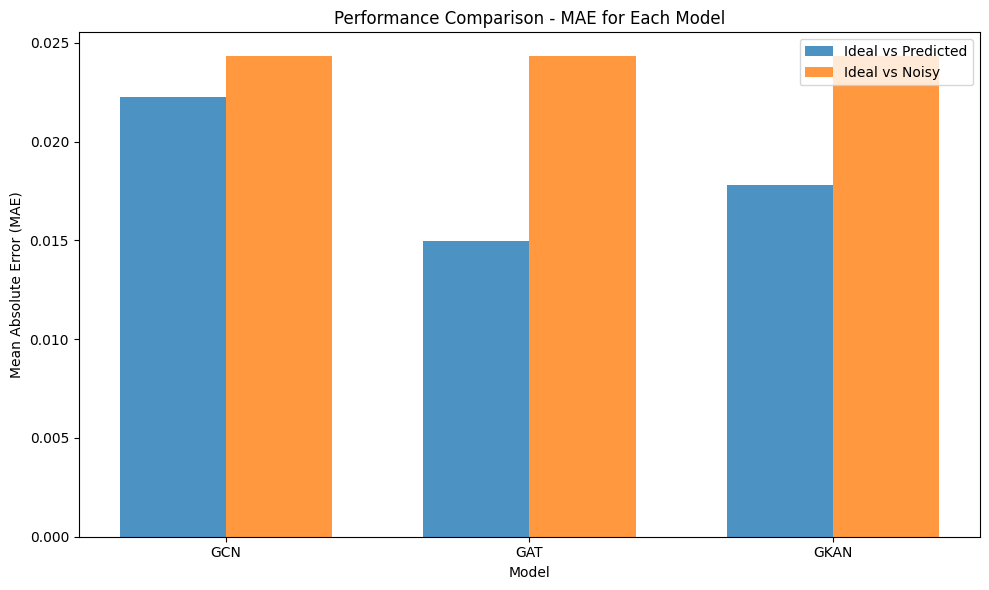

In [60]:
import matplotlib.pyplot as plt
import numpy as np

model_names = list(results.keys())
mae_pred_values = [results[name]['MAE_Pred'] for name in model_names]
mae_noisy_values = [results[name]['MAE_Noisy'] for name in model_names]

x = np.arange(len(model_names))  # label locations
width = 0.35  # width of the bars

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, mae_pred_values, width, label='Ideal vs Predicted', alpha=0.8)
plt.bar(x + width/2, mae_noisy_values, width, label='Ideal vs Noisy', alpha=0.8)

plt.xlabel('Model')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Performance Comparison - MAE for Each Model')
plt.xticks(x, model_names)
plt.legend()
plt.tight_layout()
plt.show()
